In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [14]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
... ---> a
..a ---> v
.av ---> a
ava ---> .
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [15]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [16]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [17]:
# embedding lookup table c, in the paer they took a dimension of 30, we will take of 2 to start with
C = torch.rand((27, 2))

In [18]:
C[5]

tensor([0.2852, 0.0888])

In [19]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([0.2852, 0.0888])

In [20]:
C[X].shape #torch can retrieve on tensor as well

torch.Size([32, 3, 2])

In [21]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [22]:
W1 = torch.rand((6, 100))
b1 = torch.rand(100)

In [24]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [25]:
h

tensor([[0.9947, 0.9897, 0.9898,  ..., 0.9361, 0.9790, 0.9936],
        [0.9894, 0.9856, 0.9773,  ..., 0.9169, 0.9636, 0.9767],
        [0.9841, 0.9691, 0.9728,  ..., 0.9054, 0.9554, 0.9611],
        ...,
        [0.9839, 0.9689, 0.9690,  ..., 0.8791, 0.9396, 0.9755],
        [0.9751, 0.9832, 0.9431,  ..., 0.9044, 0.9109, 0.9555],
        [0.9854, 0.9767, 0.9627,  ..., 0.9288, 0.9623, 0.9776]])

In [26]:
W2 = torch.rand((100, 27))
b2 = torch.randn(27)

In [27]:
logits = h@W2 +b2

In [31]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [38]:
sum(p.nelement() for p in parameters) # number of parameters in total
for p in parameters:
    p.requires_grad = True

In [39]:
for _ in range(100):
    
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6)@W1 + b1)
    logits = h@W2 +b2
    loss = F.cross_entropy(logits, Y)
    loss
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1*p.grad

print(loss.item())

0.33673858642578125


In [45]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)
C = torch.rand((27, 2))

In [46]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [47]:
sum(p.nelement() for p in parameters) # number of parameters in total
for p in parameters:
    p.requires_grad = True

In [49]:
for _ in range(10):
    
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6)@W1 + b1)
    logits = h@W2 +b2
    loss = F.cross_entropy(logits, Y)
    loss
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1*p.grad
    print(loss.item())

17.084491729736328
15.776533126831055
14.833341598510742
14.002607345581055
13.253263473510742
12.579920768737793
11.983104705810547
11.47049331665039
11.05185604095459
10.709587097167969


In [75]:
for _ in range(1000):

    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
    
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6)@W1 + b1)
    logits = h@W2 +b2
    loss = F.cross_entropy(logits, Y[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1*p.grad
print(loss.item())

2.8875675201416016


In [92]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6)@W1 + b1)
logits = h@W2 +b2
loss = F.cross_entropy(logits, Y)
loss

tensor(7.6044, grad_fn=<NllLossBackward0>)

## Finding a good learning rate

In [95]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)
C = torch.rand((27, 2))

In [96]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [97]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [98]:
lri = []
lossi = []

for i in range(1000):

    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
    
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6)@W1 + b1)
    logits = h@W2 +b2
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr*p.grad

    #track stats
    lri.append(lre[i])
    lossi.append(loss.item())
# print(loss.item())

20.480045318603516
22.258865356445312
16.027578353881836
21.990455627441406
21.048498153686523
21.669696807861328
19.39362907409668
16.950063705444336
19.668136596679688
20.40030860900879
19.515804290771484
17.2873592376709
18.01201629638672
18.929889678955078
17.9937686920166
17.716781616210938
21.429153442382812
20.34539794921875
19.305383682250977
19.754701614379883
19.233930587768555
19.118762969970703
17.851505279541016
19.966445922851562
18.629501342773438
17.411001205444336
18.30582618713379
20.072757720947266
18.19377326965332
20.255237579345703
16.67408561706543
18.076475143432617
18.904109954833984
16.36884117126465
15.78786849975586
19.954225540161133
16.15624237060547
17.348796844482422
18.80615234375
16.137393951416016
21.762022018432617
17.853160858154297
19.813753128051758
19.878847122192383
16.209177017211914
16.944665908813477
18.240888595581055
16.45289421081543
17.567249298095703
18.02491569519043
16.945058822631836
19.111806869506836
18.182952880859375
16.4761734008

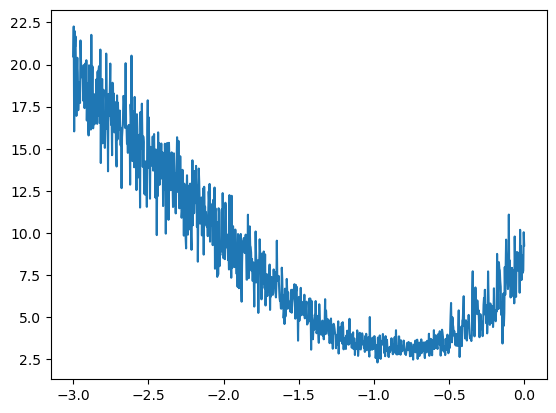

In [99]:
plt.plot(lri, lossi)

# Crank up the iteration

In [100]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)
C = torch.rand((27, 2))

In [101]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [114]:
for i in range(10000):

    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
    
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6)@W1 + b1)
    logits = h@W2 +b2
    loss = F.cross_entropy(logits, Y[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.01*p.grad # learning arte d

print(loss.item())

2.572016716003418


In [115]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6)@W1 + b1)
logits = h@W2 +b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.2957, grad_fn=<NllLossBackward0>)